In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Problem 1

In [4]:
# Load data
df = pd.read_csv('spambase/spambase.data', header=None)

# Separate features and target
X = df.iloc[:, :-1]  
y = df.iloc[:, -1] 

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [5]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Metrics
acc = accuracy_score(y_test, y_pred)
err = 1 - acc
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Error: {err:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

Confusion Matrix:
[[649  27]
 [ 62 413]]
Accuracy: 0.9227
Error: 0.0773
Precision: 0.9386
Recall: 0.8695
F1 Score: 0.9027


In [6]:
feature_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
    'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total'
]

# Get coefficients and pair with feature indices
coefs = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values('Coefficient', ascending=False)

print("Top 10 features positively correlated with SPAM:")
print(feature_importance.head(10))

print("\nTop 10 features negatively correlated with SPAM:")
print(feature_importance.tail(10))

Top 10 features positively correlated with SPAM:
                       Feature  Coefficient
52                 char_freq_$     1.157222
15              word_freq_free     0.926819
22               word_freq_000     0.923066
6             word_freq_remove     0.851676
3                 word_freq_3d     0.811284
53                 char_freq_#     0.809111
55  capital_run_length_longest     0.805998
56    capital_run_length_total     0.666252
19            word_freq_credit     0.576412
35        word_freq_technology     0.437344

Top 10 features negatively correlated with SPAM:
                 Feature  Coefficient
25         word_freq_hpl    -0.799402
44          word_freq_re    -0.809556
28         word_freq_lab    -0.904066
47  word_freq_conference    -1.038352
45         word_freq_edu    -1.127105
41     word_freq_meeting    -1.232588
43     word_freq_project    -1.414723
40          word_freq_cs    -1.581230
24          word_freq_hp    -2.652692
26      word_freq_george    -4.184433

In [7]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Threshold | Accuracy | Precision | Recall")
for t in [0.25, 0.5, 0.75, 0.9]:
    y_pred_t = (y_proba >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    print(f"  {t:.2f}     | {acc:.4f}  | {prec:.4f}   | {rec:.4f}")

Threshold | Accuracy | Precision | Recall
  0.25     | 0.9123  | 0.8502   | 0.9558
  0.50     | 0.9227  | 0.9386   | 0.8695
  0.75     | 0.8844  | 0.9548   | 0.7558
  0.90     | 0.8280  | 0.9727   | 0.6000


### Comments:
As the threshold increases, precision goes up (the model is more selective about calling something spam, so when it does, it's more likely right) but recall goes down (it misses more actual spam because the bar is higher). 

# Problem 2

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cross_entropy_loss(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    # clip to avoid log(0)
    h = np.clip(h, 1e-10, 1 - 1e-10)
    return -(1/m) * (y @ np.log(h) + (1 - y) @ np.log(1 - h))

def gradient_descent_logistic(X, y, alpha, iterations):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []
    
    for i in range(iterations):
        h = sigmoid(X @ theta)
        gradient = (1/m) * (X.T @ (h - y))
        theta = theta - alpha * gradient
        
        if (i + 1) in [10, 50, 100]:
            loss = cross_entropy_loss(X, y, theta)
            losses.append((i + 1, loss))
    
    return theta, losses

# Add bias column of 1s
X_train_gd = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled])
X_test_gd = np.column_stack([np.ones(len(X_test_scaled)), X_test_scaled])
y_train_np = y_train.values
y_test_np = y_test.values

# Test 3 learning rates
learning_rates = [0.01, 0.1, 1.0]

for alpha in learning_rates:
    print(f"Learning Rate: {alpha}")
    
    theta, losses = gradient_descent_logistic(X_train_gd, y_train_np, alpha, 100)
    
    # Print loss at 10, 50, 100 iterations
    for itr, loss in losses:
        print(f"  Iteration {itr}: Cross-Entropy Loss = {loss:.4f}")
    
    # Evaluate on training set
    y_train_pred = (sigmoid(X_train_gd @ theta) >= 0.5).astype(int)
    print(f"\n  Training Set:")
    print(f"    Accuracy:  {accuracy_score(y_train_np, y_train_pred):.4f}")
    print(f"    Precision: {precision_score(y_train_np, y_train_pred):.4f}")
    print(f"    Recall:    {recall_score(y_train_np, y_train_pred):.4f}")
    print(f"    F1:        {f1_score(y_train_np, y_train_pred):.4f}")
    
    # Evaluate on testing set
    y_test_pred = (sigmoid(X_test_gd @ theta) >= 0.5).astype(int)
    print(f"\n  Testing Set:")
    print(f"    Accuracy:  {accuracy_score(y_test_np, y_test_pred):.4f}")
    print(f"    Precision: {precision_score(y_test_np, y_test_pred):.4f}")
    print(f"    Recall:    {recall_score(y_test_np, y_test_pred):.4f}")
    print(f"    F1:        {f1_score(y_test_np, y_test_pred):.4f}")

# Print sklearn's results for comparison
print("Sklearn LogisticRegression (for comparison)")
y_sklearn_pred = model.predict(X_test_scaled)
print(f"  Accuracy:  {accuracy_score(y_test, y_sklearn_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_sklearn_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_sklearn_pred):.4f}")
print(f"  F1:        {f1_score(y_test, y_sklearn_pred):.4f}")

Learning Rate: 0.01
  Iteration 10: Cross-Entropy Loss = 0.6512
  Iteration 50: Cross-Entropy Loss = 0.5416
  Iteration 100: Cross-Entropy Loss = 0.4687

  Training Set:
    Accuracy:  0.8977
    Precision: 0.8734
    Recall:    0.8610
    F1:        0.8671

  Testing Set:
    Accuracy:  0.9036
    Precision: 0.9009
    Recall:    0.8611
    F1:        0.8805
Learning Rate: 0.1
  Iteration 10: Cross-Entropy Loss = 0.4654
  Iteration 50: Cross-Entropy Loss = 0.3241
  Iteration 100: Cross-Entropy Loss = 0.2891

  Training Set:
    Accuracy:  0.9078
    Precision: 0.9113
    Recall:    0.8445
    F1:        0.8766

  Testing Set:
    Accuracy:  0.9062
    Precision: 0.9238
    Recall:    0.8421
    F1:        0.8811
Learning Rate: 1.0
  Iteration 10: Cross-Entropy Loss = 0.2853
  Iteration 50: Cross-Entropy Loss = 0.2435
  Iteration 100: Cross-Entropy Loss = 0.2321

  Training Set:
    Accuracy:  0.9209
    Precision: 0.9236
    Recall:    0.8677
    F1:        0.8948

  Testing Set:
    

### Comments:
Learning rate comparison: The loss decreases faster with larger α. At iteration 10, α=0.01 still has loss 0.65 while α=1.0 is already at 0.29. By iteration 100, α=1.0 has the best metrics across the board.

Sklearn comparison: Result α=1.0 is very close to sklearn but slightly worse on every metric. That gap is because sklearn uses L2 regularization that converges more efficiently

# Problem 3

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

In [10]:
# Part 1: Cross-validation to select k for kNN

k_values = range(1, 21)
cv_results = []

print("kNN Cross-Validation Results:")
print(f"{'k':<5} {'Accuracy':<10} {'Error':<10} {'Precision':<10} {'Recall':<10}")

best_k = 1
best_error = 1.0

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    acc = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    prec = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='precision').mean()
    rec = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='recall').mean()
    err = 1 - acc
    
    print(f"{k:<5} {acc:<10.4f} {err:<10.4f} {prec:<10.4f} {rec:<10.4f}")
    
    if err < best_error:
        best_error = err
        best_k = k

print(f"\nBest k: {best_k} (CV Error: {best_error:.4f})")

kNN Cross-Validation Results:
k     Accuracy   Error      Precision  Recall    
1     0.9014     0.0986     0.8777     0.8670    
2     0.8933     0.1067     0.9267     0.7877    
3     0.9009     0.0991     0.8825     0.8595    
4     0.9026     0.0974     0.9215     0.8191    
5     0.9026     0.0974     0.8906     0.8543    
6     0.8997     0.1003     0.9179     0.8147    
7     0.9067     0.0933     0.8963     0.8595    
8     0.9014     0.0986     0.9177     0.8199    
9     0.9049     0.0951     0.8994     0.8505    
10    0.8971     0.1029     0.9116     0.8139    
11    0.9006     0.0994     0.8977     0.8401    
12    0.8977     0.1023     0.9151     0.8117    
13    0.8994     0.1006     0.9008     0.8326    
14    0.8965     0.1035     0.9141     0.8094    
15    0.8988     0.1012     0.9017     0.8303    
16    0.8910     0.1090     0.9090     0.7997    
17    0.8951     0.1049     0.9001     0.8214    
18    0.8904     0.1096     0.9093     0.7975    
19    0.8925     0.1

In [11]:
# Part 2: Compare all 3 classifiers

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

models = {'Logistic Regression': log_reg, 'LDA': lda, 'kNN': knn}

for name, m in models.items():
    print(f"{name}")
    
    for set_name, X_set, y_set in [('Training', X_train_scaled, y_train), ('Testing', X_test_scaled, y_test)]:
        y_pred = m.predict(X_set)
        print(f"\n  {set_name} Set:")
        print(f"    Accuracy:  {accuracy_score(y_set, y_pred):.4f}")
        print(f"    Error:     {1 - accuracy_score(y_set, y_pred):.4f}")
        print(f"    Precision: {precision_score(y_set, y_pred):.4f}")
        print(f"    Recall:    {recall_score(y_set, y_pred):.4f}")

Logistic Regression

  Training Set:
    Accuracy:  0.9258
    Error:     0.0742
    Precision: 0.9240
    Recall:    0.8812

  Testing Set:
    Accuracy:  0.9227
    Error:     0.0773
    Precision: 0.9386
    Recall:    0.8695
LDA

  Training Set:
    Accuracy:  0.8867
    Error:     0.1133
    Precision: 0.9157
    Recall:    0.7795

  Testing Set:
    Accuracy:  0.8853
    Error:     0.1147
    Precision: 0.9298
    Recall:    0.7811
kNN

  Training Set:
    Accuracy:  0.9226
    Error:     0.0774
    Precision: 0.9167
    Recall:    0.8804

  Testing Set:
    Accuracy:  0.9018
    Error:     0.0982
    Precision: 0.9114
    Recall:    0.8442


### Comments:
Logistic regression is the best on test accuracy (92.3%), followed by kNN (90.2%), then LDA (88.5%). LDA performs worst because it assumes each class follows a Gaussian distribution with shared covariance. 

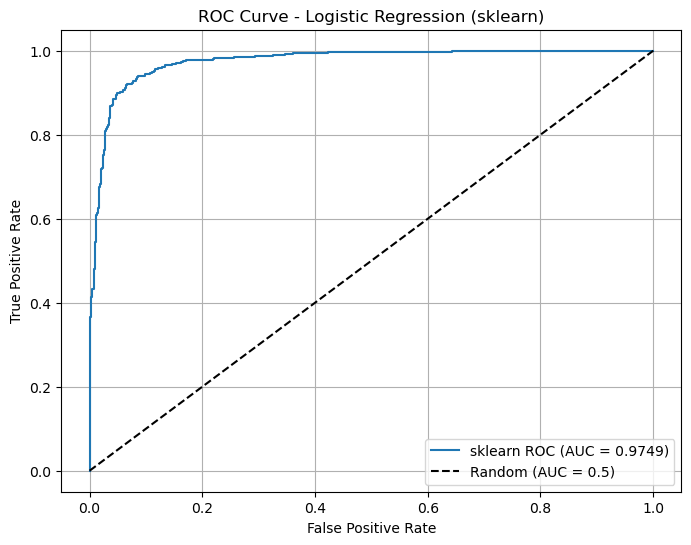

In [12]:
# Part 3: ROC curve using sklearn
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_proba_lr)
auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_sklearn, tpr_sklearn, label=f'sklearn ROC (AUC = {auc_sklearn:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (sklearn)')
plt.legend()
plt.grid(True)
plt.savefig('roc_sklearn.png')
plt.show()

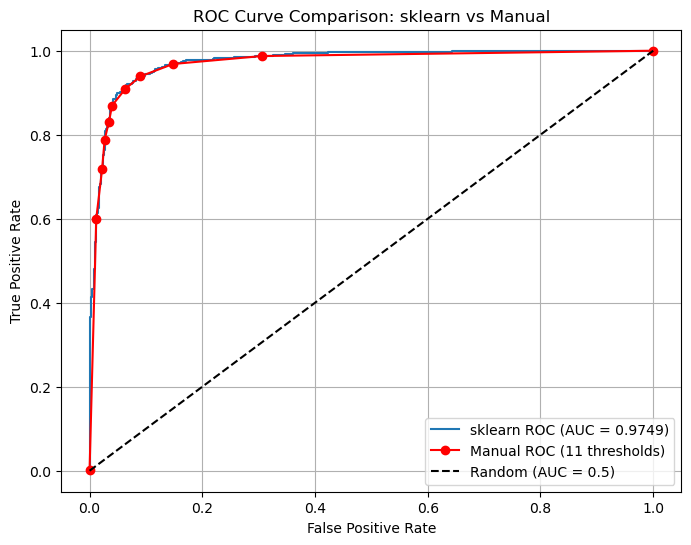

In [13]:
# Part 4: Manual ROC curve
thresholds = np.arange(0, 1.1, 0.1)
manual_fpr = []
manual_tpr = []

for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    tn = ((y_pred_t == 0) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    manual_fpr.append(fpr)
    manual_tpr.append(tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_sklearn, tpr_sklearn, label=f'sklearn ROC (AUC = {auc_sklearn:.4f})')
plt.plot(manual_fpr, manual_tpr, 'ro-', label='Manual ROC (11 thresholds)')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: sklearn vs Manual')
plt.legend()
plt.grid(True)
plt.savefig('roc_comparison.png')
plt.show()

### Comments:
The comparison plot shows the manual curve tracks sklearn's closely. The manual curve is slightly blockier in the lower-left region where thresholds are changing rapidly. To make them more similar, you'd increase the number of thresholds.

# Problem 4

In [14]:
def k_fold_cv(X, y, model_class, k, **model_params):
    n = len(y)
    indices = np.arange(n)
    np.random.seed(42)
    np.random.shuffle(indices)
    
    fold_size = n // k
    errors = []
    
    for i in range(k):
        
        # Define validation indices for this fold
        val_start = i * fold_size
        val_end = val_start + fold_size if i < k - 1 else n
        
        val_idx = indices[val_start:val_end]
        train_idx = np.concatenate([indices[:val_start], indices[val_end:]])
        
        # Split data
        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]
        
        # Scale within each fold
        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold = scaler.transform(X_val_fold)
        
        # Train and evaluate
        model = model_class(**model_params)
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        
        error = 1 - accuracy_score(y_val_fold, y_pred)
        errors.append(error)
    
    return errors, np.mean(errors)

# Convert to numpy arrays (needed for indexing)
X_all = df.iloc[:, :-1].values
y_all = df.iloc[:, -1].values

# Run CV for both models and both k values
print(f"{'Model':<25} {'k':<5} {'Avg Validation Error':<20}")
print("-" * 50)

for k in [5, 10]:
    errors_lr, avg_lr = k_fold_cv(X_all, y_all, LogisticRegression, k, max_iter=1000)
    errors_lda, avg_lda = k_fold_cv(X_all, y_all, LinearDiscriminantAnalysis, k)
    
    print(f"{'Logistic Regression':<25} {k:<5} {avg_lr:.4f}")
    print(f"{'LDA':<25} {k:<5} {avg_lda:.4f}")
    print()


Model                     k     Avg Validation Error
--------------------------------------------------
Logistic Regression       5     0.0752
LDA                       5     0.1126

Logistic Regression       10    0.0741
LDA                       10    0.1130



### Comments:
Logistic regression is better with about 7.4% error vs 11.3% for LDA, regardless of k. This is because LDA's Gaussian assumption doesn't fit word frequency data well, while logistic regression makes fewer assumptions and focuses directly on the decision boundary. k=5 vs k=10 barely matters here. The differences are tiny (0.75% vs 0.74% for LogReg, 11.3% vs 11.3% for LDA). With a dataset this large, each fold is big enough that the choice between 5 and 10 folds doesn't significantly affect the estimate.